In [93]:
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression

%load_ext autoreload
%autoreload 2
from SklearnWrapper import SklearnWrapper
from Datamodule import Datamodule
from Ensemble import Ensemble
from helpers import get_latest_run_dir, compute_uncertainties

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
LABEL_NAMES = [
    "0.T-shirt",
    "1.Trouser",
    "2.Pullover",
    "3.Dress",
    "4.Coat",
    "5.Sandal",
    "6.Shirt",
    "7.Sneaker",
    "8.Bag",
    "9.Ankle boot",
]

In [3]:
datamodule = Datamodule()
datamodule.prepare_data()
datamodule.setup("test")

In [7]:
latest_run_dir = get_latest_run_dir()
ensemble = SklearnWrapper(Ensemble(latest_run_dir), move_device=False)

['2026-06-24 13:26:58.782422', '2026-06-24 13:41:44.486169']
Latest run: 2026-06-24 13:41:44.486169
Latest run dir: checkpoints/run_2026-06-24 13:41:44.486169
Model for fold=0: checkpoints/run_2026-06-24 13:41:44.486169/fold0/model-epoch=14-val_loss=0.242.ckpt
Temperature for fold=0: 1.3736447095870972
Model for fold=1: checkpoints/run_2026-06-24 13:41:44.486169/fold1/model-epoch=11-val_loss=0.239.ckpt
Temperature for fold=1: 1.0928692817687988
Model for fold=2: checkpoints/run_2026-06-24 13:41:44.486169/fold2/model-epoch=10-val_loss=0.244.ckpt
Temperature for fold=2: 1.1840633153915405
Model for fold=3: checkpoints/run_2026-06-24 13:41:44.486169/fold3/model-epoch=14-val_loss=0.232.ckpt
Temperature for fold=3: 1.2276005744934082
Model for fold=4: checkpoints/run_2026-06-24 13:41:44.486169/fold4/model-epoch=10-val_loss=0.249.ckpt
Temperature for fold=4: 1.0976569652557373


In [5]:
accuracy = ensemble.score(datamodule.X_test, datamodule.y_test)
f"{accuracy=:.4f}"

'accuracy=0.9256'

In [105]:
def explain(X_to_explain: torch.Tensor) -> np.ndarray:
    X_to_explain = X_to_explain.reshape(784)
    num_of_perturbations = 3000
    stds = datamodule.X_test.reshape(-1, 784).std(dim=0)
    stds = stds.unsqueeze(1)

    current_class = ensemble.predict(X_to_explain)

    noise = torch.randn((X_to_explain.shape[0], num_of_perturbations)) * stds
    perturbations = X_to_explain.unsqueeze(1) + noise
    perturbations = perturbations.swapaxes(0, 1)
    distances = torch.exp(-torch.linalg.norm(perturbations - X_to_explain, dim=1))
    outputs = ensemble.predict(perturbations)
    y_surrogate = (outputs == current_class)

    perturbations = perturbations.detach().cpu().numpy()
    distances = distances.detach().cpu().numpy()
    y_surrogate = y_surrogate.detach().cpu().numpy().astype(int)

    if len(np.unique(y_surrogate)) < 2:
        # This sample was not affected by the perturbations
        return np.zeros((28, 28))

    clf = LogisticRegression(solver='liblinear', fit_intercept=False, C=1.0)
    clf.fit(perturbations, y_surrogate, sample_weight=distances)

    coef = clf.coef_[0]
    coef = coef.reshape(28, 28)
    return coef

In [ ]:
def display_explain_grid(indices_to_show) -> None:
    n_cases = len(indices_to_show)
    fig, axs = plt.subplots(figsize=(12, 3.5 * n_cases))
    outer_gs = gridspec.GridSpec(n_cases, 3, width_ratios=[1, 1, 1], hspace=0.4, wspace=0.3)

    for i, data_idx in enumerate(indices_to_show):
        ax_img = fig.add_subplot(outer_gs[i, 0])
        x = datamodule.X_test[data_idx]
        ax_img.imshow(x.squeeze(), cmap="gray")
        ax_img.axis("off")
        ax_img.set_title(LABEL_NAMES[datamodule.y_test[data_idx]], fontsize=10, pad=10)

        ax_exp = fig.add_subplot(outer_gs[i, 1])
        pixels = explain(x)
        im = ax_exp.imshow(pixels, cmap="inferno")
        ax_exp.set_title(LABEL_NAMES[datamodule.y_test[data_idx]])
        ax_exp.axis("off")
        fig.colorbar(im, ax=ax_exp, shrink=0.8)

        inner_gs = gridspec.GridSpecFromSubplotSpec(
            n_folds, 1, subplot_spec=outer_gs[i, 2], hspace=0.15
        )

        y_min, y_max = 0.0, 1.05

        for fold in range(n_folds):
            ax_fold = fig.add_subplot(inner_gs[fold, 0])

            # bars = ax_fold.bar(range(10), proba_all[fold, data_idx], color="skyblue", edgecolor="none")
            ax_fold.set_ylim(y_min, y_max)

            ax_fold.set_xticks(range(10))
            ax_fold.set_yticks([0, 0.5, 1])
            ax_fold.tick_params(axis='both', which='both', labelsize=8)

            if fold < n_folds - 1:
                ax_fold.set_xticklabels([])

    axs.axis("off")
    plt.show()

In [9]:
proba_all = ensemble.ensemble.predict_proba_all(datamodule.X_test.to(ensemble.device))
proba_all = proba_all.detach().cpu().numpy()

total_unc, aleatoric_unc, epistemic_unc = compute_uncertainties(proba_all)

In [17]:
total_unc = pd.DataFrame(total_unc, columns=["total_uncertainty"])
total_unc = total_unc.sort_values(by=total_unc.columns[0])
total_unc

,total_uncertainty
5545,4.856493e-07
8102,7.074677e-07
2677,1.037876e-06
8959,1.186125e-06
26,1.547531e-06
...,...
9682,2.507658e+00
9847,2.540473e+00
79,2.558601e+00
7793,2.653194e+00


In [18]:
most_certain = total_unc.iloc[:100]

,total_uncertainty
5545,4.856493e-07
8102,7.074677e-07
2677,1.037876e-06
8959,1.186125e-06
26,1.547531e-06
...,...
8173,1.500521e-05
4614,1.501175e-05
3402,1.506866e-05
2299,1.549439e-05


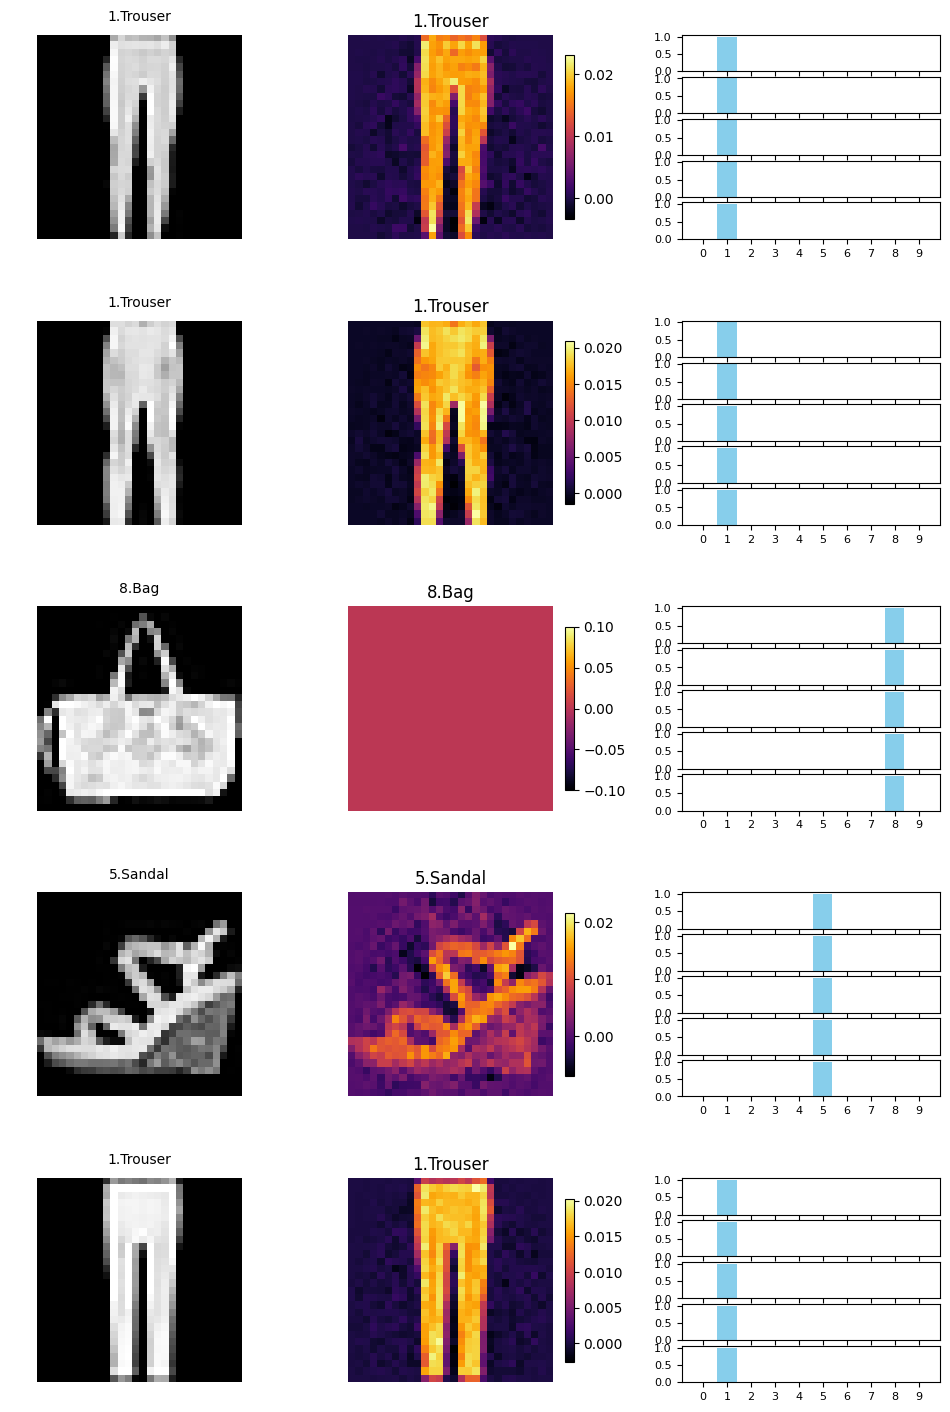

In [119]:
most_certain = total_unc.iloc[:100]
n_cases = 5
indices = np.random.choice(most_certain.index, n_cases, replace=False)
display_explain_grid(indices)

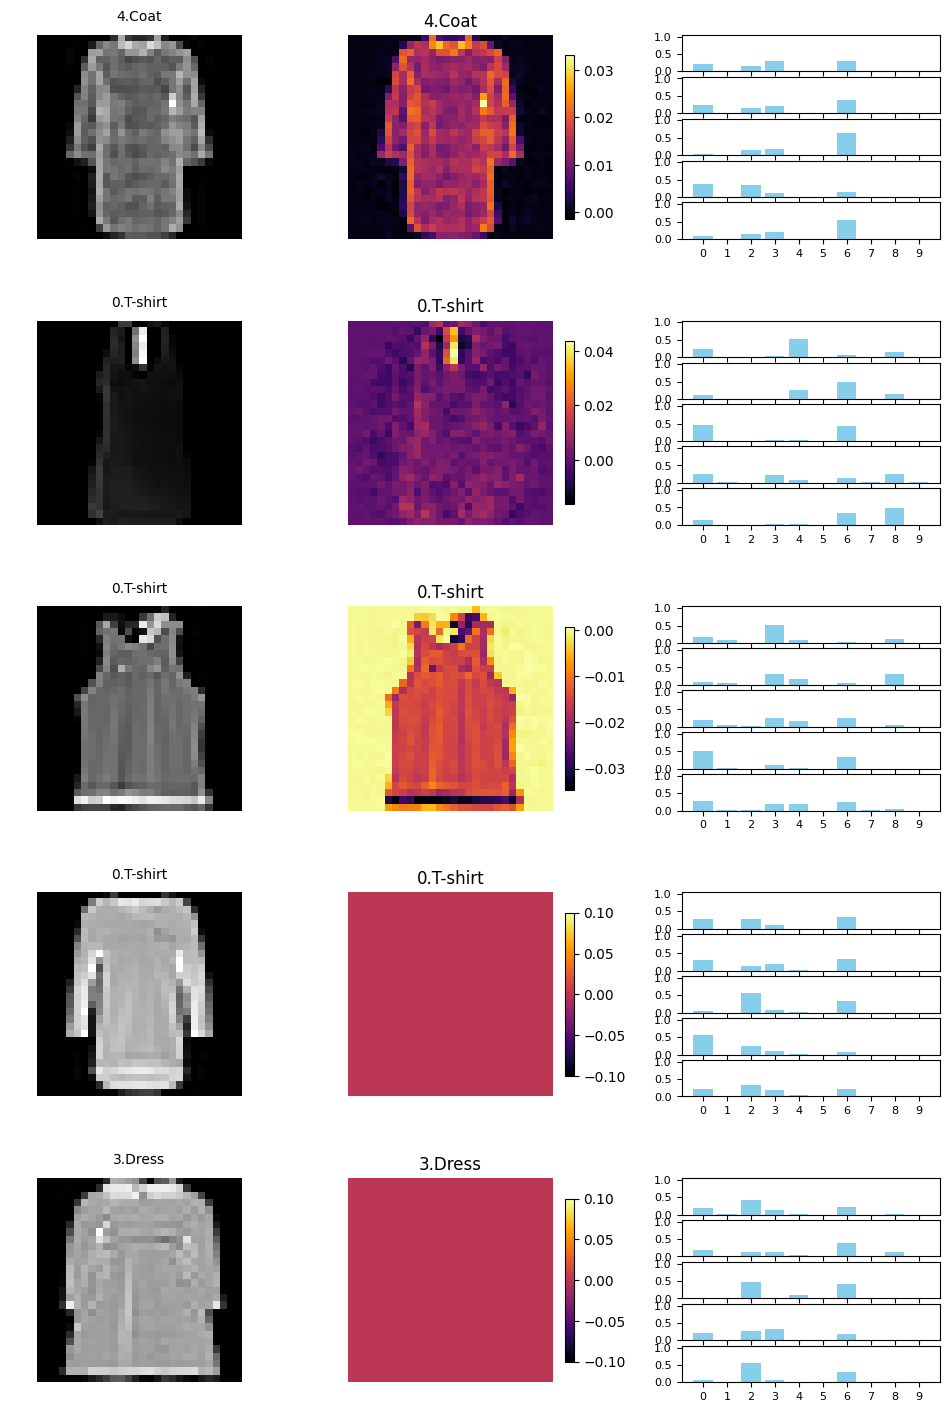

In [118]:
least_certain = total_unc.iloc[-100:]
n_cases = 5
indices = np.random.choice(least_certain.index, n_cases, replace=False)
display_explain_grid(indices)